# Phase 3 – Python Analysis

## Milestone 3.1 – Load SQL Views into Pandas

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path("C:/Projects/AnalyticsPortfolio")
db_path = project_root / "data" / "database" / "alberta_home_insurance.db"

print("Database path:", db_path)
print("Database exists:", db_path.exists())

Database path: C:\Projects\AnalyticsPortfolio\data\database\alberta_home_insurance.db
Database exists: True


In [2]:
conn = sqlite3.connect(db_path)

cpi_monthly = pd.read_sql_query(
    "SELECT * FROM vw_cpi_monthly;",
    conn
)

construction_quarterly = pd.read_sql_query(
    "SELECT * FROM vw_construction_quarterly;",
    conn
)

catastrophe_events = pd.read_sql_query(
    "SELECT * FROM vw_catastrophe_events;",
    conn
)

annual_summary = pd.read_sql_query(
    "SELECT * FROM vw_annual_summary ORDER BY year;",
    conn
)

conn.close()

print("Views loaded into pandas.")

Views loaded into pandas.


In [3]:
print("cpi_monthly:", cpi_monthly.shape)
print("construction_quarterly:", construction_quarterly.shape)
print("catastrophe_events:", catastrophe_events.shape)
print("annual_summary:", annual_summary.shape)

cpi_monthly: (360, 13)
construction_quarterly: (37, 15)
catastrophe_events: (6, 19)
annual_summary: (10, 8)


In [4]:
from pathlib import Path
import sqlite3
import pandas as pd

project_root = Path("C:/Projects/AnalyticsPortfolio")
database_path = project_root / "data" / "database" / "alberta_home_insurance.db"

print("Database path:", database_path)
print("Database exists:", database_path.exists())
print("Database size KB:", database_path.stat().st_size / 1024)

Database path: C:\Projects\AnalyticsPortfolio\data\database\alberta_home_insurance.db
Database exists: True
Database size KB: 124.0


In [5]:
conn = sqlite3.connect(database_path)

tables_check = pd.read_sql_query("""
SELECT name, type
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name;
""", conn)

display(tables_check)

,name,type
0,dim_date,table
1,fact_construction_cost,table
2,fact_cpi,table
3,fact_hail_loss_event,table
4,sqlite_sequence,table
5,vw_annual_summary,view
6,vw_catastrophe_events,view
7,vw_construction_quarterly,view
8,vw_cpi_monthly,view


In [6]:
row_count_check = pd.read_sql_query("""
SELECT 'dim_date' AS table_name, COUNT(*) AS row_count FROM dim_date
UNION ALL
SELECT 'fact_cpi', COUNT(*) FROM fact_cpi
UNION ALL
SELECT 'fact_construction_cost', COUNT(*) FROM fact_construction_cost
UNION ALL
SELECT 'fact_hail_loss_event', COUNT(*) FROM fact_hail_loss_event
UNION ALL
SELECT 'vw_annual_summary', COUNT(*) FROM vw_annual_summary;
""", conn)

display(row_count_check)

,table_name,row_count
0,dim_date,121
1,fact_cpi,360
2,fact_construction_cost,37
3,fact_hail_loss_event,6
4,vw_annual_summary,10


In [7]:
annual_summary = pd.read_sql_query("""
SELECT *
FROM vw_annual_summary
ORDER BY year;
""", conn)

print("annual_summary shape:", annual_summary.shape)
display(annual_summary)

annual_summary shape: (10, 8)


,year,five_year_cohort,alberta_all_items_cpi_avg,alberta_home_insurance_cpi_avg,canada_home_insurance_cpi_avg,alberta_residential_construction_index_avg,catastrophe_event_count,total_revised_catastrophe_loss_cad
0,2016,2016-2020,135.166667,356.075000,219.066667,NaN,0,NaN
1,2017,2016-2020,137.250000,364.733333,225.808333,58.050,0,NaN
2,2018,2016-2020,140.633333,372.041667,234.358333,60.750,0,NaN
3,2019,2016-2020,143.066667,384.333333,248.150000,61.675,0,NaN
4,2020,2016-2020,144.658333,409.658333,262.008333,64.100,1,1.300000e+09
5,2021,2021-2025,149.266667,439.133333,275.266667,80.425,1,7.000000e+08
6,2022,2021-2025,158.925000,471.191667,295.800000,97.050,0,NaN
7,2023,2021-2025,164.141667,509.816667,318.250000,100.000,1,1.100000e+08
8,2024,2021-2025,168.908333,562.241667,342.900000,105.650,1,3.293000e+09
9,2025,2021-2025,172.191667,621.875000,360.341667,110.425,2,3.990000e+08


## Milestone 3.2 – Baseline Trend Tables

### Calculate percent change from baseline year

This step calculates percent change from the 2016 baseline for CPI series.

In [8]:
annual_trends = annual_summary.copy()

baseline_year = 2016

baseline_values = annual_trends.loc[
    annual_trends["year"] == baseline_year,
    [
        "alberta_all_items_cpi_avg",
        "alberta_home_insurance_cpi_avg",
        "canada_home_insurance_cpi_avg"
    ]
].iloc[0]

annual_trends["alberta_all_items_pct_change_since_2016"] = (
    (annual_trends["alberta_all_items_cpi_avg"] / baseline_values["alberta_all_items_cpi_avg"]) - 1
) * 100

annual_trends["alberta_home_insurance_pct_change_since_2016"] = (
    (annual_trends["alberta_home_insurance_cpi_avg"] / baseline_values["alberta_home_insurance_cpi_avg"]) - 1
) * 100

annual_trends["canada_home_insurance_pct_change_since_2016"] = (
    (annual_trends["canada_home_insurance_cpi_avg"] / baseline_values["canada_home_insurance_cpi_avg"]) - 1
) * 100

annual_trends[
    [
        "year",
        "five_year_cohort",
        "alberta_all_items_pct_change_since_2016",
        "alberta_home_insurance_pct_change_since_2016",
        "canada_home_insurance_pct_change_since_2016",
        "catastrophe_event_count",
        "total_revised_catastrophe_loss_cad"
    ]
]

,year,five_year_cohort,alberta_all_items_pct_change_since_2016,alberta_home_insurance_pct_change_since_2016,canada_home_insurance_pct_change_since_2016,catastrophe_event_count,total_revised_catastrophe_loss_cad
0,2016,2016-2020,0.000000,0.000000,0.000000,0,NaN
1,2017,2016-2020,1.541307,2.431604,3.077450,0,NaN
2,2018,2016-2020,4.044390,4.484074,6.980371,0,NaN
3,2019,2016-2020,5.844636,7.936062,13.276019,0,NaN
4,2020,2016-2020,7.022195,15.048328,19.602100,1,1.300000e+09
5,2021,2021-2025,10.431566,23.326078,25.654291,1,7.000000e+08
6,2022,2021-2025,17.577065,32.329331,35.027389,0,NaN
7,2023,2021-2025,21.436498,43.176765,45.275411,1,1.100000e+08
8,2024,2021-2025,24.963009,57.899787,56.527693,1,3.293000e+09
9,2025,2021-2025,27.392109,74.647195,64.489501,2,3.990000e+08


In [9]:
construction_baseline_year = 2017

construction_baseline = annual_trends.loc[
    annual_trends["year"] == construction_baseline_year,
    "alberta_residential_construction_index_avg"
].iloc[0]

annual_trends["alberta_construction_pct_change_since_2017"] = (
    (annual_trends["alberta_residential_construction_index_avg"] / construction_baseline) - 1
) * 100

annual_trends[
    [
        "year",
        "five_year_cohort",
        "alberta_home_insurance_pct_change_since_2016",
        "alberta_all_items_pct_change_since_2016",
        "canada_home_insurance_pct_change_since_2016",
        "alberta_construction_pct_change_since_2017",
        "catastrophe_event_count",
        "total_revised_catastrophe_loss_cad"
    ]
]

,year,five_year_cohort,alberta_home_insurance_pct_change_since_2016,alberta_all_items_pct_change_since_2016,canada_home_insurance_pct_change_since_2016,alberta_construction_pct_change_since_2017,catastrophe_event_count,total_revised_catastrophe_loss_cad
0,2016,2016-2020,0.000000,0.000000,0.000000,NaN,0,NaN
1,2017,2016-2020,2.431604,1.541307,3.077450,0.000000,0,NaN
2,2018,2016-2020,4.484074,4.044390,6.980371,4.651163,0,NaN
3,2019,2016-2020,7.936062,5.844636,13.276019,6.244617,0,NaN
4,2020,2016-2020,15.048328,7.022195,19.602100,10.422050,1,1.300000e+09
5,2021,2021-2025,23.326078,10.431566,25.654291,38.544358,1,7.000000e+08
6,2022,2021-2025,32.329331,17.577065,35.027389,67.183463,0,NaN
7,2023,2021-2025,43.176765,21.436498,45.275411,72.265289,1,1.100000e+08
8,2024,2021-2025,57.899787,24.963009,56.527693,81.998277,1,3.293000e+09
9,2025,2021-2025,74.647195,27.392109,64.489501,90.223945,2,3.990000e+08


In [10]:
annual_trends["ab_insurance_minus_ab_all_items_gap_pct_points"] = (
    annual_trends["alberta_home_insurance_pct_change_since_2016"]
    - annual_trends["alberta_all_items_pct_change_since_2016"]
)

annual_trends["ab_insurance_minus_canada_insurance_gap_pct_points"] = (
    annual_trends["alberta_home_insurance_pct_change_since_2016"]
    - annual_trends["canada_home_insurance_pct_change_since_2016"]
)

annual_trends["ab_insurance_minus_construction_gap_pct_points"] = (
    annual_trends["alberta_home_insurance_pct_change_since_2016"]
    - annual_trends["alberta_construction_pct_change_since_2017"]
)

divergence_table = annual_trends[
    [
        "year",
        "five_year_cohort",
        "alberta_home_insurance_pct_change_since_2016",
        "alberta_all_items_pct_change_since_2016",
        "canada_home_insurance_pct_change_since_2016",
        "alberta_construction_pct_change_since_2017",
        "ab_insurance_minus_ab_all_items_gap_pct_points",
        "ab_insurance_minus_canada_insurance_gap_pct_points",
        "ab_insurance_minus_construction_gap_pct_points",
        "catastrophe_event_count",
        "total_revised_catastrophe_loss_cad"
    ]
]

divergence_table

,year,five_year_cohort,alberta_home_insurance_pct_change_since_2016,alberta_all_items_pct_change_since_2016,canada_home_insurance_pct_change_since_2016,alberta_construction_pct_change_since_2017,ab_insurance_minus_ab_all_items_gap_pct_points,ab_insurance_minus_canada_insurance_gap_pct_points,ab_insurance_minus_construction_gap_pct_points,catastrophe_event_count,total_revised_catastrophe_loss_cad
0,2016,2016-2020,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0,NaN
1,2017,2016-2020,2.431604,1.541307,3.077450,0.000000,0.890297,-0.645846,2.431604,0,NaN
2,2018,2016-2020,4.484074,4.044390,6.980371,4.651163,0.439684,-2.496297,-0.167089,0,NaN
3,2019,2016-2020,7.936062,5.844636,13.276019,6.244617,2.091426,-5.339957,1.691445,0,NaN
4,2020,2016-2020,15.048328,7.022195,19.602100,10.422050,8.026133,-4.553772,4.626278,1,1.300000e+09
5,2021,2021-2025,23.326078,10.431566,25.654291,38.544358,12.894512,-2.328213,-15.218280,1,7.000000e+08
6,2022,2021-2025,32.329331,17.577065,35.027389,67.183463,14.752266,-2.698058,-34.854131,0,NaN
7,2023,2021-2025,43.176765,21.436498,45.275411,72.265289,21.740267,-2.098646,-29.088523,1,1.100000e+08
8,2024,2021-2025,57.899787,24.963009,56.527693,81.998277,32.936778,1.372094,-24.098490,1,3.293000e+09
9,2025,2021-2025,74.647195,27.392109,64.489501,90.223945,47.255087,10.157694,-15.576750,2,3.990000e+08


## Milestone 3.3 – Growth and Divergence Metrics

In [11]:
start_year = 2016
end_year = 2025

start_row = annual_summary.loc[annual_summary["year"] == start_year].iloc[0]
end_row = annual_summary.loc[annual_summary["year"] == end_year].iloc[0]

change_summary = pd.DataFrame({
    "metric": [
        "Alberta All-items CPI",
        "Alberta Home Insurance CPI",
        "Canada Home Insurance CPI"
    ],
    "start_year": [start_year, start_year, start_year],
    "end_year": [end_year, end_year, end_year],
    "start_value": [
        start_row["alberta_all_items_cpi_avg"],
        start_row["alberta_home_insurance_cpi_avg"],
        start_row["canada_home_insurance_cpi_avg"]
    ],
    "end_value": [
        end_row["alberta_all_items_cpi_avg"],
        end_row["alberta_home_insurance_cpi_avg"],
        end_row["canada_home_insurance_cpi_avg"]
    ]
})

change_summary["absolute_change"] = (
    change_summary["end_value"] - change_summary["start_value"]
)

change_summary["percent_change"] = (
    (change_summary["end_value"] / change_summary["start_value"]) - 1
) * 100

change_summary

,metric,start_year,end_year,start_value,end_value,absolute_change,percent_change
0,Alberta All-items CPI,2016,2025,135.166667,172.191667,37.025,27.392109
1,Alberta Home Insurance CPI,2016,2025,356.075000,621.875000,265.800,74.647195
2,Canada Home Insurance CPI,2016,2025,219.066667,360.341667,141.275,64.489501


In [12]:
gap_2025 = divergence_table.loc[
    divergence_table["year"] == 2025,
    [
        "year",
        "alberta_home_insurance_pct_change_since_2016",
        "alberta_all_items_pct_change_since_2016",
        "canada_home_insurance_pct_change_since_2016",
        "alberta_construction_pct_change_since_2017",
        "ab_insurance_minus_ab_all_items_gap_pct_points",
        "ab_insurance_minus_canada_insurance_gap_pct_points",
        "ab_insurance_minus_construction_gap_pct_points"
    ]
].copy()

gap_2025

,year,alberta_home_insurance_pct_change_since_2016,alberta_all_items_pct_change_since_2016,canada_home_insurance_pct_change_since_2016,alberta_construction_pct_change_since_2017,ab_insurance_minus_ab_all_items_gap_pct_points,ab_insurance_minus_canada_insurance_gap_pct_points,ab_insurance_minus_construction_gap_pct_points
9,2025,74.647195,27.392109,64.489501,90.223945,47.255087,10.157694,-15.57675


In [13]:
cohort_summary = annual_trends.groupby("five_year_cohort").agg(
    alberta_all_items_cpi_avg=("alberta_all_items_cpi_avg", "mean"),
    alberta_home_insurance_cpi_avg=("alberta_home_insurance_cpi_avg", "mean"),
    canada_home_insurance_cpi_avg=("canada_home_insurance_cpi_avg", "mean"),
    alberta_construction_index_avg=("alberta_residential_construction_index_avg", "mean"),
    total_catastrophe_events=("catastrophe_event_count", "sum"),
    total_revised_catastrophe_loss_cad=("total_revised_catastrophe_loss_cad", "sum")
).reset_index()

cohort_summary

,five_year_cohort,alberta_all_items_cpi_avg,alberta_home_insurance_cpi_avg,canada_home_insurance_cpi_avg,alberta_construction_index_avg,total_catastrophe_events,total_revised_catastrophe_loss_cad
0,2016-2020,140.155000,377.368333,237.878333,61.14375,1,1.300000e+09
1,2021-2025,162.686667,520.851667,318.511667,98.71000,5,4.502000e+09


In [14]:
annual_trends = annual_trends.sort_values("year").copy()

annual_trends["alberta_home_insurance_yoy_pct_change"] = (
    annual_trends["alberta_home_insurance_cpi_avg"].pct_change() * 100
)

largest_ab_insurance_jump = annual_trends[
    [
        "year",
        "alberta_home_insurance_cpi_avg",
        "alberta_home_insurance_yoy_pct_change",
        "catastrophe_event_count",
        "total_revised_catastrophe_loss_cad"
    ]
].sort_values(
    "alberta_home_insurance_yoy_pct_change",
    ascending=False
)

largest_ab_insurance_jump

,year,alberta_home_insurance_cpi_avg,alberta_home_insurance_yoy_pct_change,catastrophe_event_count,total_revised_catastrophe_loss_cad
9,2025,621.875000,10.606353,2,3.990000e+08
8,2024,562.241667,10.283108,1,3.293000e+09
7,2023,509.816667,8.197301,1,1.100000e+08
6,2022,471.191667,7.300364,0,NaN
5,2021,439.133333,7.195020,1,7.000000e+08
4,2020,409.658333,6.589332,1,1.300000e+09
3,2019,384.333333,3.303841,0,NaN
1,2017,364.733333,2.431604,0,NaN
2,2018,372.041667,2.003747,0,NaN
0,2016,356.075000,NaN,0,NaN


## Milestone 3.4 – Add Catastrophe Event Context

In [15]:
event_context = catastrophe_events[
    [
        "event_id",
        "event_date",
        "year",
        "year_month",
        "event_name",
        "primary_region",
        "peril_type",
        "revised_loss_cad",
        "loss_source",
        "notes"
    ]
].copy()

event_context = event_context.sort_values(["event_date", "event_id"])

event_context

,event_id,event_date,year,year_month,event_name,primary_region,peril_type,revised_loss_cad,loss_source,notes
0,1,2020-06-13,2020,2020-06,Calgary Hailstorm,Calgary,Hail / Convective Storm,1.300000e+09,IBC (CatIQ),One of Canada's costliest hail events.
1,2,2021-07-02,2021,2021-07,Calgary Hailstorm,Calgary,Hail / Convective Storm,7.000000e+08,IBC (CatIQ),Mentioned by IBC as a major recent Calgary hai...
2,3,2023-07-15,2023,2023-07,South Calgary Hailstorm,Calgary,Hail / Convective Storm,1.100000e+08,IBC,"Damaged homes, vehicles and commercial property."
3,4,2024-08-05,2024,2024-08,Calgary Hailstorm,Calgary,Hail / Convective Storm,3.293000e+09,PERILS / CatIQ,Record revised estimate after claims development.
4,5,2025-07-13,2025,2025-07,Calgary Hailstorm,Calgary,Hail / Convective Storm,1.640000e+08,IBC (CatIQ),"Initial estimate $92M, later revised to $164M."
5,6,2025-08-20,2025,2025-08,Brooks Severe Storm,Brooks,Severe Convective Storm,2.350000e+08,IBC (CatIQ),Included because it is a major Alberta insured...


In [16]:
annual_event_context = annual_trends.copy()

annual_event_context["has_catastrophe_event"] = annual_event_context["catastrophe_event_count"] > 0

annual_event_context["catastrophe_loss_cad_filled"] = (
    annual_event_context["total_revised_catastrophe_loss_cad"].fillna(0)
)

annual_event_context[
    [
        "year",
        "five_year_cohort",
        "alberta_home_insurance_cpi_avg",
        "alberta_home_insurance_yoy_pct_change",
        "alberta_home_insurance_pct_change_since_2016",
        "catastrophe_event_count",
        "has_catastrophe_event",
        "catastrophe_loss_cad_filled"
    ]
]

,year,five_year_cohort,alberta_home_insurance_cpi_avg,alberta_home_insurance_yoy_pct_change,alberta_home_insurance_pct_change_since_2016,catastrophe_event_count,has_catastrophe_event,catastrophe_loss_cad_filled
0,2016,2016-2020,356.075000,NaN,0.000000,0,False,0.000000e+00
1,2017,2016-2020,364.733333,2.431604,2.431604,0,False,0.000000e+00
2,2018,2016-2020,372.041667,2.003747,4.484074,0,False,0.000000e+00
3,2019,2016-2020,384.333333,3.303841,7.936062,0,False,0.000000e+00
4,2020,2016-2020,409.658333,6.589332,15.048328,1,True,1.300000e+09
5,2021,2021-2025,439.133333,7.195020,23.326078,1,True,7.000000e+08
6,2022,2021-2025,471.191667,7.300364,32.329331,0,False,0.000000e+00
7,2023,2021-2025,509.816667,8.197301,43.176765,1,True,1.100000e+08
8,2024,2021-2025,562.241667,10.283108,57.899787,1,True,3.293000e+09
9,2025,2021-2025,621.875000,10.606353,74.647195,2,True,3.990000e+08


In [17]:
event_year_comparison = annual_event_context.groupby("has_catastrophe_event").agg(
    year_count=("year", "count"),
    avg_home_insurance_yoy_pct_change=("alberta_home_insurance_yoy_pct_change", "mean"),
    avg_home_insurance_pct_change_since_2016=("alberta_home_insurance_pct_change_since_2016", "mean"),
    total_catastrophe_events=("catastrophe_event_count", "sum"),
    total_catastrophe_loss_cad=("catastrophe_loss_cad_filled", "sum")
).reset_index()

event_year_comparison["has_catastrophe_event"] = event_year_comparison["has_catastrophe_event"].map({
    False: "No curated event",
    True: "Curated event year"
})

event_year_comparison

,has_catastrophe_event,year_count,avg_home_insurance_yoy_pct_change,avg_home_insurance_pct_change_since_2016,total_catastrophe_events,total_catastrophe_loss_cad
0,No curated event,5,3.759889,9.436214,0,0.000000e+00
1,Curated event year,5,8.574223,42.819631,6,5.802000e+09


In [18]:
cohort_event_context = annual_event_context.groupby("five_year_cohort").agg(
    year_count=("year", "count"),
    avg_home_insurance_yoy_pct_change=("alberta_home_insurance_yoy_pct_change", "mean"),
    avg_home_insurance_pct_change_since_2016=("alberta_home_insurance_pct_change_since_2016", "mean"),
    total_catastrophe_events=("catastrophe_event_count", "sum"),
    total_catastrophe_loss_cad=("catastrophe_loss_cad_filled", "sum")
).reset_index()

cohort_event_context

,five_year_cohort,year_count,avg_home_insurance_yoy_pct_change,avg_home_insurance_pct_change_since_2016,total_catastrophe_events,total_catastrophe_loss_cad
0,2016-2020,5,3.582131,5.980014,1,1.300000e+09
1,2021-2025,5,8.716429,46.275831,5,4.502000e+09


### Event Context Interpretation

Curated catastrophe events are used as contextual markers, not causal proof.

The event table includes selected major Alberta insured-loss events from 2020 to 2025. These events are concentrated in the later cohort, 2021–2025, which also shows higher Alberta home insurance CPI levels and stronger cumulative growth.

Event years had higher average year-over-year Alberta home insurance CPI growth than non-event years in this dataset. However, this comparison is descriptive only because the sample is small and the event table is curated rather than exhaustive.

This pattern supports further stakeholder review, but the analysis does not prove that any single event caused a specific premium increase. Insurance premiums may reflect multiple factors, including accumulated claims experience, replacement-cost pressure, reinsurance costs, actuarial pricing cycles, regulatory approval timing, and broader market recalibration.

In [19]:
from pathlib import Path

figures_path = project_root / "outputs" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

print("Figures folder:")
print(figures_path)
print("Exists:", figures_path.exists())

Figures folder:
C:\Projects\AnalyticsPortfolio\outputs\figures
Exists: True


In [20]:
for var_name in ["cpi_clean", "construction_clean", "events_clean", "dim_date_clean"]:
    print(var_name, "exists:", var_name in globals())

cpi_clean exists: False
construction_clean exists: False
events_clean exists: False
dim_date_clean exists: False


In [21]:
for var_name in [
    "cpi_monthly",
    "construction_quarterly",
    "catastrophe_events",
    "annual_summary"
]:
    print(var_name, "exists:", var_name in globals())

cpi_monthly exists: True
construction_quarterly exists: True
catastrophe_events exists: True
annual_summary exists: True


In [22]:
print("cpi_monthly:", cpi_monthly.shape)
print("construction_quarterly:", construction_quarterly.shape)
print("catastrophe_events:", catastrophe_events.shape)
print("annual_summary:", annual_summary.shape)

cpi_monthly: (360, 13)
construction_quarterly: (37, 15)
catastrophe_events: (6, 19)
annual_summary: (10, 8)


In [23]:
row_count_check = pd.read_sql_query("""
SELECT 'dim_date' AS table_name, COUNT(*) AS row_count FROM dim_date
UNION ALL
SELECT 'fact_cpi', COUNT(*) FROM fact_cpi
UNION ALL
SELECT 'fact_construction_cost', COUNT(*) FROM fact_construction_cost
UNION ALL
SELECT 'fact_hail_loss_event', COUNT(*) FROM fact_hail_loss_event
UNION ALL
SELECT 'vw_cpi_monthly', COUNT(*) FROM vw_cpi_monthly
UNION ALL
SELECT 'vw_construction_quarterly', COUNT(*) FROM vw_construction_quarterly
UNION ALL
SELECT 'vw_catastrophe_events', COUNT(*) FROM vw_catastrophe_events
UNION ALL
SELECT 'vw_annual_summary', COUNT(*) FROM vw_annual_summary;
""", conn)

display(row_count_check)

,table_name,row_count
0,dim_date,121
1,fact_cpi,360
2,fact_construction_cost,37
3,fact_hail_loss_event,6
4,vw_cpi_monthly,360
5,vw_construction_quarterly,37
6,vw_catastrophe_events,6
7,vw_annual_summary,10


In [24]:
display(annual_summary)

,year,five_year_cohort,alberta_all_items_cpi_avg,alberta_home_insurance_cpi_avg,canada_home_insurance_cpi_avg,alberta_residential_construction_index_avg,catastrophe_event_count,total_revised_catastrophe_loss_cad
0,2016,2016-2020,135.166667,356.075000,219.066667,NaN,0,NaN
1,2017,2016-2020,137.250000,364.733333,225.808333,58.050,0,NaN
2,2018,2016-2020,140.633333,372.041667,234.358333,60.750,0,NaN
3,2019,2016-2020,143.066667,384.333333,248.150000,61.675,0,NaN
4,2020,2016-2020,144.658333,409.658333,262.008333,64.100,1,1.300000e+09
5,2021,2021-2025,149.266667,439.133333,275.266667,80.425,1,7.000000e+08
6,2022,2021-2025,158.925000,471.191667,295.800000,97.050,0,NaN
7,2023,2021-2025,164.141667,509.816667,318.250000,100.000,1,1.100000e+08
8,2024,2021-2025,168.908333,562.241667,342.900000,105.650,1,3.293000e+09
9,2025,2021-2025,172.191667,621.875000,360.341667,110.425,2,3.990000e+08


In [25]:
cpi_chart_data = cpi_monthly.copy()

cpi_chart_data["calendar_date"] = pd.to_datetime(cpi_chart_data["calendar_date"])

cpi_chart_data["series"] = (
    cpi_chart_data["geography"] + " – " + cpi_chart_data["cpi_category"]
)

cpi_chart_data = cpi_chart_data.sort_values(["series", "calendar_date"])

print("CPI chart data shape:", cpi_chart_data.shape)

display(
    cpi_chart_data[
        ["calendar_date", "geography", "cpi_category", "cpi_value", "series"]
    ].head()
)

CPI chart data shape: (360, 14)


,calendar_date,geography,cpi_category,cpi_value,series
120,2016-01-01,Alberta,All-items,133.7,Alberta – All-items
121,2016-02-01,Alberta,All-items,133.8,Alberta – All-items
122,2016-03-01,Alberta,All-items,135.0,Alberta – All-items
123,2016-04-01,Alberta,All-items,135.1,Alberta – All-items
124,2016-05-01,Alberta,All-items,135.6,Alberta – All-items


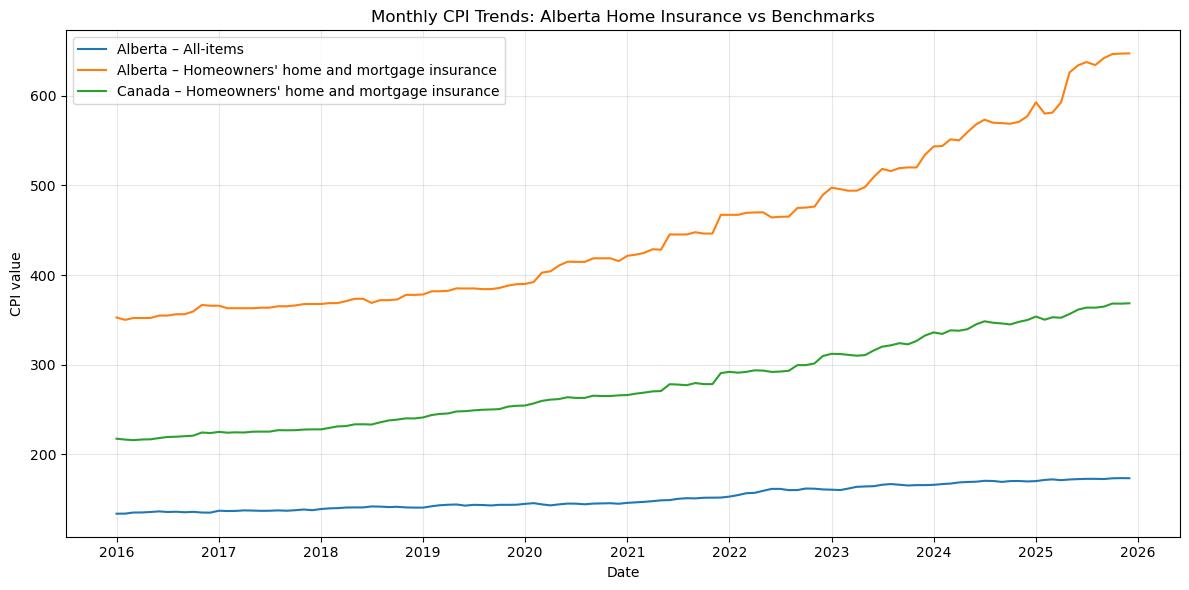

Saved chart: C:\Projects\AnalyticsPortfolio\outputs\figures\monthly_cpi_trends.png


In [26]:
plt.figure(figsize=(12, 6))

for series_name, group in cpi_chart_data.groupby("series"):
    plt.plot(
        group["calendar_date"],
        group["cpi_value"],
        label=series_name
    )

plt.title("Monthly CPI Trends: Alberta Home Insurance vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("CPI value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

chart_path = figures_path / "monthly_cpi_trends.png"
plt.savefig(chart_path, dpi=300)
plt.show()

print("Saved chart:", chart_path)

In [27]:
saved_figures = sorted(figures_path.glob("*.png"))

print("Saved figures:")
for figure in saved_figures:
    print("-", figure.name)

Saved figures:
- alberta_home_vs_auto_insurance_sensitivity.png
- cpi_only_indexed_growth_comparison.png
- curated_catastrophe_losses_by_year.png
- indexed_growth_comparison.png
- insurance_yoy_with_event_years.png
- monthly_cpi_trends.png


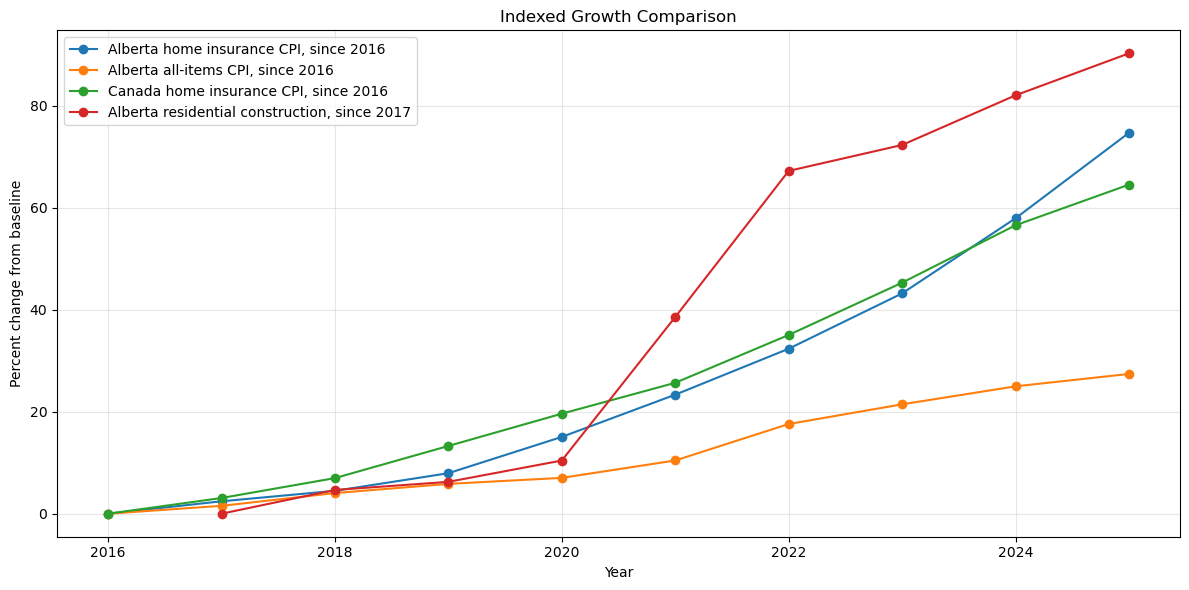

Saved chart: C:\Projects\AnalyticsPortfolio\outputs\figures\indexed_growth_comparison.png


In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    divergence_table["year"],
    divergence_table["alberta_home_insurance_pct_change_since_2016"],
    marker="o",
    label="Alberta home insurance CPI, since 2016"
)

plt.plot(
    divergence_table["year"],
    divergence_table["alberta_all_items_pct_change_since_2016"],
    marker="o",
    label="Alberta all-items CPI, since 2016"
)

plt.plot(
    divergence_table["year"],
    divergence_table["canada_home_insurance_pct_change_since_2016"],
    marker="o",
    label="Canada home insurance CPI, since 2016"
)

plt.plot(
    divergence_table["year"],
    divergence_table["alberta_construction_pct_change_since_2017"],
    marker="o",
    label="Alberta residential construction, since 2017"
)

plt.title("Indexed Growth Comparison")
plt.xlabel("Year")
plt.ylabel("Percent change from baseline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

chart_path = figures_path / "indexed_growth_comparison.png"
plt.savefig(chart_path, dpi=300)
plt.show()

print("Saved chart:", chart_path)

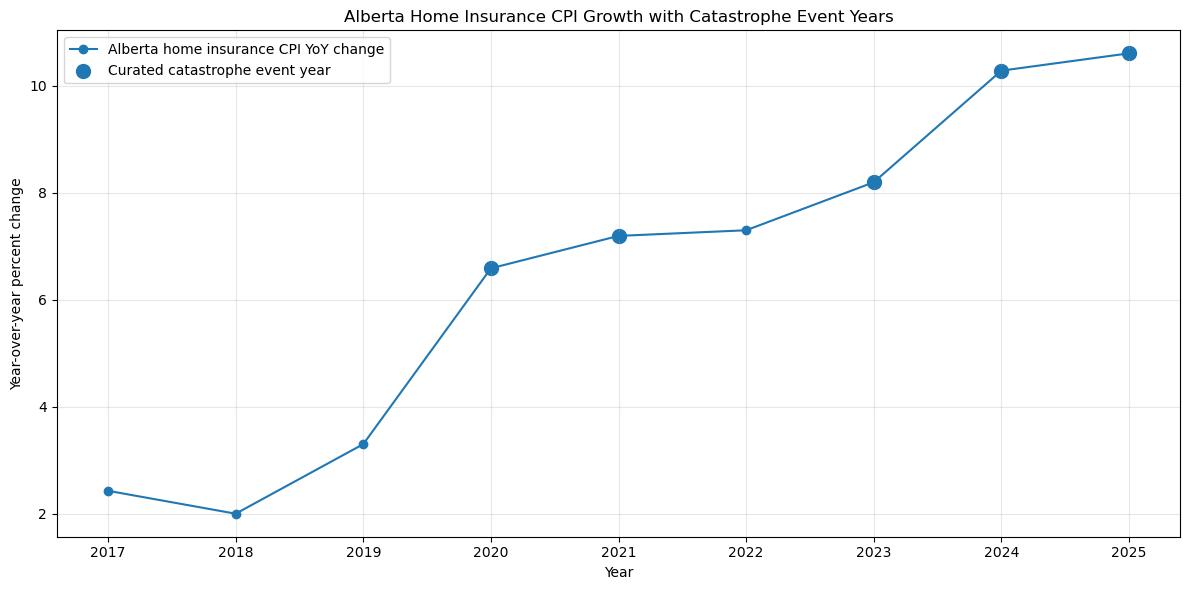

Saved chart: C:\Projects\AnalyticsPortfolio\outputs\figures\insurance_yoy_with_event_years.png


In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    annual_event_context["year"],
    annual_event_context["alberta_home_insurance_yoy_pct_change"],
    marker="o",
    label="Alberta home insurance CPI YoY change"
)

event_years = annual_event_context[
    annual_event_context["has_catastrophe_event"]
]

plt.scatter(
    event_years["year"],
    event_years["alberta_home_insurance_yoy_pct_change"],
    s=100,
    label="Curated catastrophe event year"
)

plt.title("Alberta Home Insurance CPI Growth with Catastrophe Event Years")
plt.xlabel("Year")
plt.ylabel("Year-over-year percent change")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

chart_path = figures_path / "insurance_yoy_with_event_years.png"
plt.savefig(chart_path, dpi=300)
plt.show()

print("Saved chart:", chart_path)

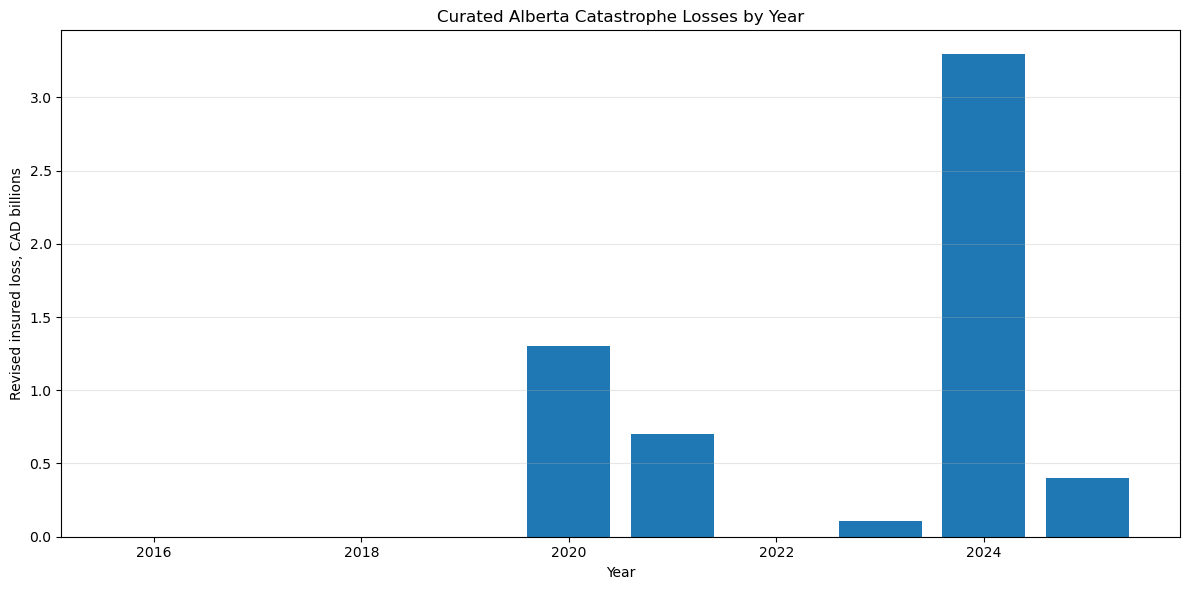

Saved chart: C:\Projects\AnalyticsPortfolio\outputs\figures\curated_catastrophe_losses_by_year.png


In [30]:
loss_by_year = annual_event_context.copy()

plt.figure(figsize=(12, 6))

plt.bar(
    loss_by_year["year"],
    loss_by_year["catastrophe_loss_cad_filled"] / 1_000_000_000
)

plt.title("Curated Alberta Catastrophe Losses by Year")
plt.xlabel("Year")
plt.ylabel("Revised insured loss, CAD billions")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

chart_path = figures_path / "curated_catastrophe_losses_by_year.png"
plt.savefig(chart_path, dpi=300)
plt.show()

print("Saved chart:", chart_path)

In [31]:
saved_figures = sorted(figures_path.glob("*.png"))

print("Saved figures:")
for figure in saved_figures:
    print("-", figure.name)

Saved figures:
- alberta_home_vs_auto_insurance_sensitivity.png
- cpi_only_indexed_growth_comparison.png
- curated_catastrophe_losses_by_year.png
- indexed_growth_comparison.png
- insurance_yoy_with_event_years.png
- monthly_cpi_trends.png


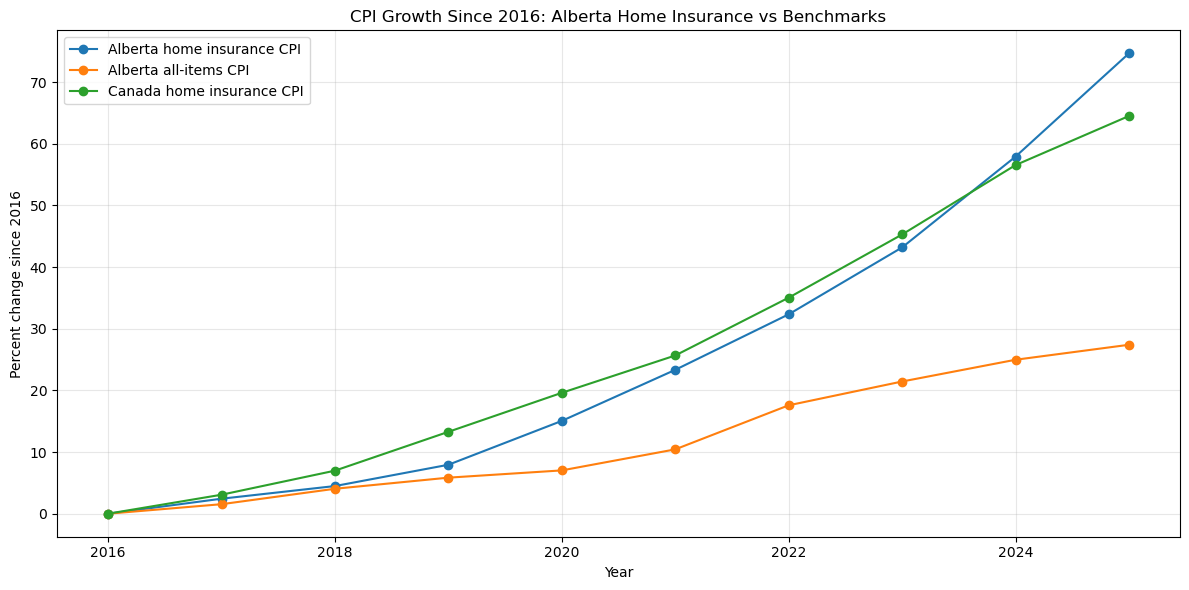

Saved chart: C:\Projects\AnalyticsPortfolio\outputs\figures\cpi_only_indexed_growth_comparison.png


In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    divergence_table["year"],
    divergence_table["alberta_home_insurance_pct_change_since_2016"],
    marker="o",
    label="Alberta home insurance CPI"
)

plt.plot(
    divergence_table["year"],
    divergence_table["alberta_all_items_pct_change_since_2016"],
    marker="o",
    label="Alberta all-items CPI"
)

plt.plot(
    divergence_table["year"],
    divergence_table["canada_home_insurance_pct_change_since_2016"],
    marker="o",
    label="Canada home insurance CPI"
)

plt.title("CPI Growth Since 2016: Alberta Home Insurance vs Benchmarks")
plt.xlabel("Year")
plt.ylabel("Percent change since 2016")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

chart_path = figures_path / "cpi_only_indexed_growth_comparison.png"
plt.savefig(chart_path, dpi=300)
plt.show()

print("Saved chart:", chart_path)

In [33]:
saved_figures = sorted(figures_path.glob("*.png"))

print("Saved figures:")
for figure in saved_figures:
    print("-", figure.name)

Saved figures:
- alberta_home_vs_auto_insurance_sensitivity.png
- cpi_only_indexed_growth_comparison.png
- curated_catastrophe_losses_by_year.png
- indexed_growth_comparison.png
- insurance_yoy_with_event_years.png
- monthly_cpi_trends.png


## Milestone 3.6 – Interpret Findings
### Preliminary Findings

#### Finding 1 – Alberta home insurance CPI grew much faster than Alberta general inflation

From 2016 to 2025, Alberta home insurance CPI increased by approximately 74.6%, compared with approximately 27.4% for Alberta all-items CPI.

This indicates that home insurance costs increased far faster than general consumer prices in Alberta during the study period.

#### Finding 2 – Alberta home insurance CPI exceeded Canada-wide home insurance CPI growth by 2025

From 2016 to 2025, Alberta home insurance CPI increased by approximately 74.6%, while Canada home insurance CPI increased by approximately 64.5%.

Alberta was not consistently above the Canada benchmark throughout the full period, but by 2025 Alberta showed stronger cumulative growth.

#### Finding 3 – Construction costs provide important replacement-cost context

Alberta residential construction costs increased sharply from 2017 to 2025, rising approximately 90.2% from the selected construction baseline.

This benchmark is useful as replacement-cost context, but it uses a 2017 baseline because the selected construction series begins in 2017. Therefore, construction comparisons are less directly aligned than CPI-to-CPI comparisons.

#### Finding 4 – Catastrophe events cluster in the later cohort

The curated catastrophe event table includes one major insured-loss event in 2016–2020 and five events in 2021–2025.

The later cohort also shows higher average Alberta home insurance CPI growth and higher total curated insured catastrophe losses.

This pattern supports further stakeholder review, but it does not prove that any individual event caused a specific premium increase.

#### Finding 5 – Premium growth appears cumulative rather than isolated

Alberta home insurance CPI increased every year from 2016 to 2025, with the largest year-over-year increases occurring in 2024 and 2025.

However, the pattern appears gradual and cumulative rather than a single isolated spike. This may reflect delayed insurance pricing adjustments, accumulated catastrophe-loss experience, replacement-cost pressure, and broader market recalibration.

The analysis does not determine whether prices are peaking, stabilizing, or likely to continue increasing.

#### Finding 6 – Sensitivity check suggests broader insurance pressure may also be present

The auto insurance CPI sensitivity check suggests that some Alberta insurance premium pressure may be broader than home insurance alone.

From 2016 to 2025, Alberta passenger vehicle insurance CPI increased by approximately 67.7%, compared with approximately 74.6% for Alberta home insurance CPI and approximately 27.4% for Alberta all-items CPI.

This means home insurance still exceeded auto insurance growth by approximately 7.0 percentage points by 2025, supporting further review of home/property-specific pressure while avoiding the claim that premium pressure was isolated to home insurance.

### Interpretation Caveat

This analysis is descriptive and exploratory. It identifies divergence between Alberta home insurance CPI and selected benchmarks, and it uses curated catastrophe events as timing/context markers.

It does not estimate causal effects, forecast future premiums, or isolate the individual impact of climate change, reinsurance costs, regulatory decisions, construction costs, or insurer pricing models.

## Milestone 3.7 – Phase Review
### Phase 3 Outcome

Phase 3 – Python Analysis was completed successfully.

Completed work:

- Loaded SQL views into pandas.
- Created annual trend tables.
- Calculated percent change from baseline.
- Calculated benchmark divergence gaps.
- Created five-year cohort summaries.
- Added catastrophe event context.
- Created preliminary Python charts.
- Identified main stakeholder chart candidate.
- Drafted preliminary findings and interpretation caveats.
- Added optional auto insurance CPI sensitivity check.

### Key Analysis Tables Created

- `annual_trends`
- `divergence_table`
- `change_summary`
- `gap_2025`
- `cohort_summary`
- `largest_ab_insurance_jump`
- `event_context`
- `annual_event_context`
- `event_year_comparison`
- `cohort_event_context`

### Charts Created

Saved in `outputs/figures/`:

- `monthly_cpi_trends.png`
- `indexed_growth_comparison.png`
- `cpi_only_indexed_growth_comparison.png`
- `insurance_yoy_with_event_years.png`
- `curated_catastrophe_losses_by_year.png`
- `alberta_home_vs_auto_insurance_sensitivity.png`

### Main Chart Candidate

`cpi_only_indexed_growth_comparison.png`

Reason:

This chart compares Alberta home insurance CPI, Alberta all-items CPI, and Canada home insurance CPI using the same 2016 baseline. It is the cleanest and most defensible chart for the main stakeholder story.

### Supporting Charts

`indexed_growth_comparison.png`

Useful for construction replacement-cost context, but it requires a caveat because the construction benchmark begins in 2017.

`insurance_yoy_with_event_years.png`

Useful for showing event timing context, but it should not be interpreted causally.

`curated_catastrophe_losses_by_year.png`

Useful for showing the concentration of major curated insured-loss events in the later period.

`alberta_home_vs_auto_insurance_sensitivity.png`

Useful as a sensitivity check to test whether Alberta home insurance growth appears broader across insurance categories or more concentrated in home/property insurance.

### Main Preliminary Findings

1. Alberta home insurance CPI grew much faster than Alberta general inflation.
2. Alberta home insurance CPI exceeded Canada-wide home insurance CPI growth by 2025.
3. Construction costs provide important replacement-cost context, but use a 2017 baseline.
4. Curated catastrophe events cluster in the later cohort.
5. Premium growth appears cumulative rather than isolated.
6. The auto insurance CPI sensitivity check suggests that some Alberta insurance premium pressure may be broader than home insurance alone, but home insurance still exceeded auto insurance growth by 2025.

### Known Limitations

- The analysis is descriptive and exploratory.
- The catastrophe event table is curated, not exhaustive.
- Catastrophe events are used as contextual markers, not causal proof.
- Construction comparison uses a 2017 baseline because the selected construction series begins in 2017.
- The analysis does not forecast future premiums.
- The analysis does not isolate the effects of climate change, reinsurance costs, regulatory decisions, construction costs, or insurer pricing models.
- Auto insurance CPI is used only as a sensitivity check. It has different pricing drivers from home insurance, including vehicle repair costs, injury claims, theft, collision trends, regulatory rate controls, and auto-specific market conditions.

### Phase 3 Status

Phase 3 approved, including optional auto insurance CPI sensitivity check.

Ready for Phase 4 – Dashboard / Visualization.

In [34]:
saved_figures = sorted(figures_path.glob("*.png"))

print("Saved figures:")
for figure in saved_figures:
    print("-", figure.name)

Saved figures:
- alberta_home_vs_auto_insurance_sensitivity.png
- cpi_only_indexed_growth_comparison.png
- curated_catastrophe_losses_by_year.png
- indexed_growth_comparison.png
- insurance_yoy_with_event_years.png
- monthly_cpi_trends.png


## Phase 3.8 – Optional Sensitivity Check: Auto Insurance CPI

This section adds a small sensitivity check using Alberta passenger vehicle insurance CPI.

The purpose is to compare Alberta home insurance CPI against another Alberta insurance line to test whether premium pressure appears broad across insurance categories or more concentrated in home/property insurance.

This is not a core benchmark and does not prove causality.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path("C:/Projects/AnalyticsPortfolio")
raw_data_path = project_root / "data" / "raw"
figures_path = project_root / "outputs" / "figures"

figures_path.mkdir(parents=True, exist_ok=True)

auto_cpi_file = raw_data_path / "1810000401_databaseLoadingData_filtered_autoCPI.csv"

print("Project root:", project_root)
print("Raw data path:", raw_data_path)
print("Figures path:", figures_path)
print("Auto CPI file exists:", auto_cpi_file.exists())

Project root: C:\Projects\AnalyticsPortfolio
Raw data path: C:\Projects\AnalyticsPortfolio\data\raw
Figures path: C:\Projects\AnalyticsPortfolio\outputs\figures
Auto CPI file exists: True


In [36]:
auto_sensitivity_raw = pd.read_csv(
    auto_cpi_file,
    encoding="utf-8-sig",
    low_memory=False
)

print("Raw shape:", auto_sensitivity_raw.shape)
print("\nColumns:")
print(auto_sensitivity_raw.columns.tolist())

display(auto_sensitivity_raw.head())

print("\nGeographies:")
display(auto_sensitivity_raw["GEO"].value_counts())

print("\nProduct categories:")
display(auto_sensitivity_raw["Products and product groups"].value_counts())

Raw shape: (360, 15)

Columns:
['REF_DATE', 'GEO', 'DGUID', 'Products and product groups', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


,REF_DATE,GEO,DGUID,Products and product groups,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2016-01,Alberta,2016A000248,All-items,2002=100,17,units,0,v41692327,23.2,133.7,NaN,NaN,NaN,1
1,2016-02,Alberta,2016A000248,All-items,2002=100,17,units,0,v41692327,23.2,133.8,NaN,NaN,NaN,1
2,2016-03,Alberta,2016A000248,All-items,2002=100,17,units,0,v41692327,23.2,135.0,NaN,NaN,NaN,1
3,2016-04,Alberta,2016A000248,All-items,2002=100,17,units,0,v41692327,23.2,135.1,NaN,NaN,NaN,1
4,2016-05,Alberta,2016A000248,All-items,2002=100,17,units,0,v41692327,23.2,135.6,NaN,NaN,NaN,1



Geographies:


GEO
Alberta    360
Name: count, dtype: int64


Product categories:


Products and product groups
All-items                                  120
Homeowners' home and mortgage insurance    120
Passenger vehicle insurance premiums       120
Name: count, dtype: int64

In [37]:
sensitivity_categories = [
    "All-items",
    "Homeowners' home and mortgage insurance",
    "Passenger vehicle insurance premiums"
]

auto_sensitivity_clean = auto_sensitivity_raw[
    (auto_sensitivity_raw["GEO"] == "Alberta") &
    (auto_sensitivity_raw["Products and product groups"].isin(sensitivity_categories)) &
    (auto_sensitivity_raw["REF_DATE"] >= "2016-01") &
    (auto_sensitivity_raw["REF_DATE"] <= "2025-12")
].copy()

auto_sensitivity_clean = auto_sensitivity_clean.rename(columns={
    "REF_DATE": "year_month",
    "GEO": "geography",
    "Products and product groups": "cpi_category",
    "VALUE": "cpi_value"
})

auto_sensitivity_clean["calendar_date"] = pd.to_datetime(
    auto_sensitivity_clean["year_month"] + "-01"
)

auto_sensitivity_clean["year"] = auto_sensitivity_clean["calendar_date"].dt.year
auto_sensitivity_clean["date_id"] = auto_sensitivity_clean["year_month"].str.replace("-", "").astype(int)

auto_sensitivity_clean = auto_sensitivity_clean[
    [
        "date_id",
        "calendar_date",
        "year_month",
        "year",
        "geography",
        "cpi_category",
        "cpi_value"
    ]
].sort_values(["cpi_category", "date_id"])

print("Sensitivity clean shape:", auto_sensitivity_clean.shape)

display(auto_sensitivity_clean.head())
display(auto_sensitivity_clean.tail())

print("\nRows by category:")
display(
    auto_sensitivity_clean
    .groupby("cpi_category")
    .agg(
        row_count=("date_id", "count"),
        min_date_id=("date_id", "min"),
        max_date_id=("date_id", "max"),
        min_value=("cpi_value", "min"),
        max_value=("cpi_value", "max")
    )
    .reset_index()
)

Sensitivity clean shape: (360, 7)


,date_id,calendar_date,year_month,year,geography,cpi_category,cpi_value
0,201601,2016-01-01,2016-01,2016,Alberta,All-items,133.7
1,201602,2016-02-01,2016-02,2016,Alberta,All-items,133.8
2,201603,2016-03-01,2016-03,2016,Alberta,All-items,135.0
3,201604,2016-04-01,2016-04,2016,Alberta,All-items,135.1
4,201605,2016-05-01,2016-05,2016,Alberta,All-items,135.6


,date_id,calendar_date,year_month,year,geography,cpi_category,cpi_value
355,202508,2025-08-01,2025-08,2025,Alberta,Passenger vehicle insurance premiums,346.5
356,202509,2025-09-01,2025-09,2025,Alberta,Passenger vehicle insurance premiums,352.5
357,202510,2025-10-01,2025-10,2025,Alberta,Passenger vehicle insurance premiums,361.5
358,202511,2025-11-01,2025-11,2025,Alberta,Passenger vehicle insurance premiums,357.7
359,202512,2025-12-01,2025-12,2025,Alberta,Passenger vehicle insurance premiums,359.9



Rows by category:


,cpi_category,row_count,min_date_id,max_date_id,min_value,max_value
0,All-items,120,201601,202512,133.7,173.4
1,Homeowners' home and mortgage insurance,120,201601,202512,350.0,647.4
2,Passenger vehicle insurance premiums,120,201601,202512,195.1,361.5


In [38]:
auto_sensitivity_annual = (
    auto_sensitivity_clean
    .groupby(["year", "cpi_category"], as_index=False)
    .agg(avg_cpi_value=("cpi_value", "mean"))
)

auto_sensitivity_pivot = auto_sensitivity_annual.pivot(
    index="year",
    columns="cpi_category",
    values="avg_cpi_value"
).reset_index()

auto_sensitivity_pivot.columns.name = None

auto_sensitivity_pivot = auto_sensitivity_pivot.rename(columns={
    "All-items": "alberta_all_items_cpi_avg",
    "Homeowners' home and mortgage insurance": "alberta_home_insurance_cpi_avg",
    "Passenger vehicle insurance premiums": "alberta_auto_insurance_cpi_avg"
})

auto_sensitivity_pivot

,year,alberta_all_items_cpi_avg,alberta_home_insurance_cpi_avg,alberta_auto_insurance_cpi_avg
0,2016,135.166667,356.075000,199.575000
1,2017,137.250000,364.733333,199.500000
2,2018,140.633333,372.041667,204.925000
3,2019,143.066667,384.333333,221.541667
4,2020,144.658333,409.658333,251.208333
5,2021,149.266667,439.133333,264.333333
6,2022,158.925000,471.191667,273.341667
7,2023,164.141667,509.816667,282.791667
8,2024,168.908333,562.241667,298.416667
9,2025,172.191667,621.875000,334.608333


In [39]:
baseline_year = 2016

baseline = auto_sensitivity_pivot.loc[
    auto_sensitivity_pivot["year"] == baseline_year
].iloc[0]

auto_sensitivity_pivot["alberta_all_items_pct_change_since_2016"] = (
    (auto_sensitivity_pivot["alberta_all_items_cpi_avg"] / baseline["alberta_all_items_cpi_avg"]) - 1
) * 100

auto_sensitivity_pivot["alberta_home_insurance_pct_change_since_2016"] = (
    (auto_sensitivity_pivot["alberta_home_insurance_cpi_avg"] / baseline["alberta_home_insurance_cpi_avg"]) - 1
) * 100

auto_sensitivity_pivot["alberta_auto_insurance_pct_change_since_2016"] = (
    (auto_sensitivity_pivot["alberta_auto_insurance_cpi_avg"] / baseline["alberta_auto_insurance_cpi_avg"]) - 1
) * 100

auto_sensitivity_pivot["home_minus_auto_gap_pct_points"] = (
    auto_sensitivity_pivot["alberta_home_insurance_pct_change_since_2016"]
    - auto_sensitivity_pivot["alberta_auto_insurance_pct_change_since_2016"]
)

auto_sensitivity_pivot[
    [
        "year",
        "alberta_home_insurance_pct_change_since_2016",
        "alberta_auto_insurance_pct_change_since_2016",
        "alberta_all_items_pct_change_since_2016",
        "home_minus_auto_gap_pct_points"
    ]
]

,year,alberta_home_insurance_pct_change_since_2016,alberta_auto_insurance_pct_change_since_2016,alberta_all_items_pct_change_since_2016,home_minus_auto_gap_pct_points
0,2016,0.000000,0.000000,0.000000,0.000000
1,2017,2.431604,-0.037580,1.541307,2.469184
2,2018,4.484074,2.680696,4.044390,1.803378
3,2019,7.936062,11.006723,5.844636,-3.070660
4,2020,15.048328,25.871644,7.022195,-10.823316
5,2021,23.326078,32.448119,10.431566,-9.122041
6,2022,32.329331,36.961877,17.577065,-4.632546
7,2023,43.176765,41.696939,21.436498,1.479826
8,2024,57.899787,49.526076,24.963009,8.373711
9,2025,74.647195,67.660445,27.392109,6.986750


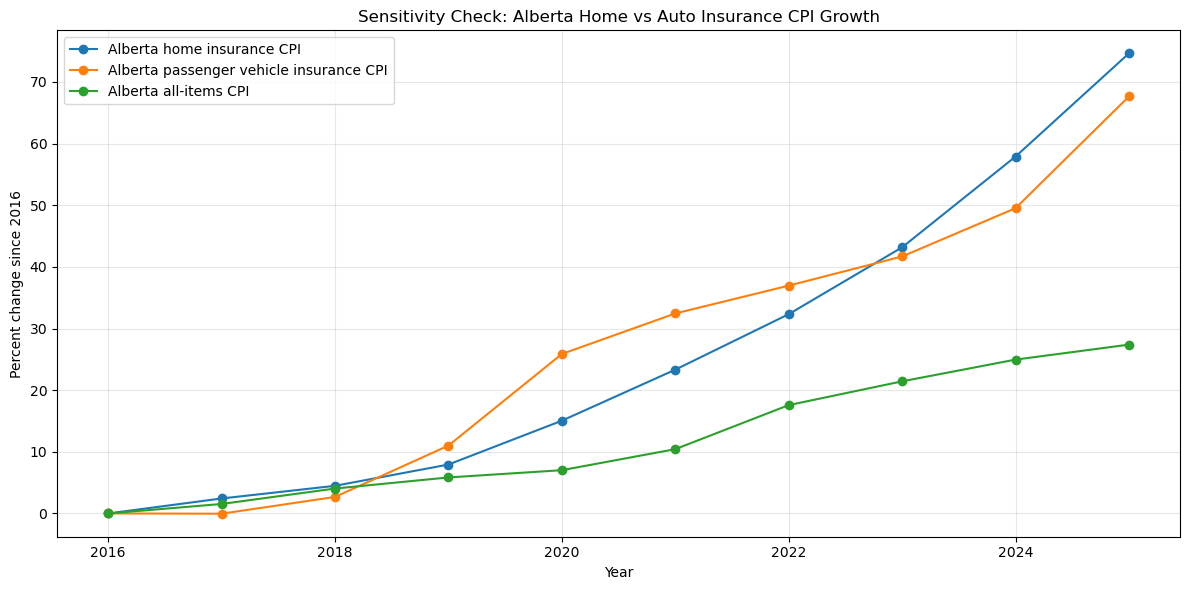

Saved chart: C:\Projects\AnalyticsPortfolio\outputs\figures\alberta_home_vs_auto_insurance_sensitivity.png


In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    auto_sensitivity_pivot["year"],
    auto_sensitivity_pivot["alberta_home_insurance_pct_change_since_2016"],
    marker="o",
    label="Alberta home insurance CPI"
)

plt.plot(
    auto_sensitivity_pivot["year"],
    auto_sensitivity_pivot["alberta_auto_insurance_pct_change_since_2016"],
    marker="o",
    label="Alberta passenger vehicle insurance CPI"
)

plt.plot(
    auto_sensitivity_pivot["year"],
    auto_sensitivity_pivot["alberta_all_items_pct_change_since_2016"],
    marker="o",
    label="Alberta all-items CPI"
)

plt.title("Sensitivity Check: Alberta Home vs Auto Insurance CPI Growth")
plt.xlabel("Year")
plt.ylabel("Percent change since 2016")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

chart_path = figures_path / "alberta_home_vs_auto_insurance_sensitivity.png"
plt.savefig(chart_path, dpi=300)
plt.show()

print("Saved chart:", chart_path)

In [41]:
auto_sensitivity_2025 = auto_sensitivity_pivot.loc[
    auto_sensitivity_pivot["year"] == 2025,
    [
        "year",
        "alberta_home_insurance_pct_change_since_2016",
        "alberta_auto_insurance_pct_change_since_2016",
        "alberta_all_items_pct_change_since_2016",
        "home_minus_auto_gap_pct_points"
    ]
]

auto_sensitivity_2025

,year,alberta_home_insurance_pct_change_since_2016,alberta_auto_insurance_pct_change_since_2016,alberta_all_items_pct_change_since_2016,home_minus_auto_gap_pct_points
9,2025,74.647195,67.660445,27.392109,6.98675


### Sensitivity Check Interpretation

Alberta passenger vehicle insurance CPI was added as a sensitivity check to compare home insurance against another Alberta insurance line.

From 2016 to 2025, Alberta home insurance CPI increased by approximately 74.6%, while Alberta passenger vehicle insurance CPI increased by approximately 67.7%. Both series rose much faster than Alberta all-items CPI, which increased by approximately 27.4%.

This suggests that Alberta home insurance premium growth was not entirely isolated from broader insurance-market pressure. Auto insurance also experienced substantial cumulative growth during the period.

However, Alberta home insurance CPI exceeded auto insurance CPI by approximately 7.0 percentage points by 2025. This later-period divergence is consistent with the possibility that home/property-specific pressures, such as catastrophe exposure, rebuild costs, and replacement-cost inflation, added pressure beyond broader insurance-market inflation.

This comparison is descriptive only. Auto insurance has different pricing drivers, including vehicle repair costs, injury claims, theft, collision trends, regulatory rate controls, and auto-specific market conditions. Therefore, auto insurance CPI is treated as a sensitivity check rather than a main benchmark or causal test.

## Milestone 4.2 – Prepare Dashboard Data

This section exports clean dashboard-ready CSV files for Power BI.

The exported files are designed to keep Power BI transformation work minimal and preserve the validated analysis logic from Python and SQL.

In [42]:
from pathlib import Path

dashboard_data_path = project_root / "outputs" / "dashboard_data"
dashboard_data_path.mkdir(parents=True, exist_ok=True)

print("Dashboard data path:", dashboard_data_path)
print("Folder exists:", dashboard_data_path.exists())

Dashboard data path: C:\Projects\AnalyticsPortfolio\outputs\dashboard_data
Folder exists: True


In [43]:
dashboard_annual_summary = annual_summary.copy()

dashboard_annual_summary.to_csv(
    dashboard_data_path / "dashboard_annual_summary.csv",
    index=False
)

print("Exported dashboard_annual_summary.csv")
print("Shape:", dashboard_annual_summary.shape)
display(dashboard_annual_summary.head())

Exported dashboard_annual_summary.csv
Shape: (10, 8)


,year,five_year_cohort,alberta_all_items_cpi_avg,alberta_home_insurance_cpi_avg,canada_home_insurance_cpi_avg,alberta_residential_construction_index_avg,catastrophe_event_count,total_revised_catastrophe_loss_cad
0,2016,2016-2020,135.166667,356.075000,219.066667,NaN,0,NaN
1,2017,2016-2020,137.250000,364.733333,225.808333,58.050,0,NaN
2,2018,2016-2020,140.633333,372.041667,234.358333,60.750,0,NaN
3,2019,2016-2020,143.066667,384.333333,248.150000,61.675,0,NaN
4,2020,2016-2020,144.658333,409.658333,262.008333,64.100,1,1.300000e+09


In [44]:
dashboard_cpi_indexed_growth = divergence_table[
    [
        "year",
        "five_year_cohort",
        "alberta_home_insurance_pct_change_since_2016",
        "alberta_all_items_pct_change_since_2016",
        "canada_home_insurance_pct_change_since_2016",
        "ab_insurance_minus_ab_all_items_gap_pct_points",
        "ab_insurance_minus_canada_insurance_gap_pct_points",
        "catastrophe_event_count",
        "total_revised_catastrophe_loss_cad"
    ]
].copy()

dashboard_cpi_indexed_growth.to_csv(
    dashboard_data_path / "dashboard_cpi_indexed_growth.csv",
    index=False
)

print("Exported dashboard_cpi_indexed_growth.csv")
print("Shape:", dashboard_cpi_indexed_growth.shape)
display(dashboard_cpi_indexed_growth)

Exported dashboard_cpi_indexed_growth.csv
Shape: (10, 9)


,year,five_year_cohort,alberta_home_insurance_pct_change_since_2016,alberta_all_items_pct_change_since_2016,canada_home_insurance_pct_change_since_2016,ab_insurance_minus_ab_all_items_gap_pct_points,ab_insurance_minus_canada_insurance_gap_pct_points,catastrophe_event_count,total_revised_catastrophe_loss_cad
0,2016,2016-2020,0.000000,0.000000,0.000000,0.000000,0.000000,0,NaN
1,2017,2016-2020,2.431604,1.541307,3.077450,0.890297,-0.645846,0,NaN
2,2018,2016-2020,4.484074,4.044390,6.980371,0.439684,-2.496297,0,NaN
3,2019,2016-2020,7.936062,5.844636,13.276019,2.091426,-5.339957,0,NaN
4,2020,2016-2020,15.048328,7.022195,19.602100,8.026133,-4.553772,1,1.300000e+09
5,2021,2021-2025,23.326078,10.431566,25.654291,12.894512,-2.328213,1,7.000000e+08
6,2022,2021-2025,32.329331,17.577065,35.027389,14.752266,-2.698058,0,NaN
7,2023,2021-2025,43.176765,21.436498,45.275411,21.740267,-2.098646,1,1.100000e+08
8,2024,2021-2025,57.899787,24.963009,56.527693,32.936778,1.372094,1,3.293000e+09
9,2025,2021-2025,74.647195,27.392109,64.489501,47.255087,10.157694,2,3.990000e+08


In [45]:
dashboard_catastrophe_events = event_context.copy()

dashboard_catastrophe_events.to_csv(
    dashboard_data_path / "dashboard_catastrophe_events.csv",
    index=False
)

print("Exported dashboard_catastrophe_events.csv")
print("Shape:", dashboard_catastrophe_events.shape)
display(dashboard_catastrophe_events)

Exported dashboard_catastrophe_events.csv
Shape: (6, 10)


,event_id,event_date,year,year_month,event_name,primary_region,peril_type,revised_loss_cad,loss_source,notes
0,1,2020-06-13,2020,2020-06,Calgary Hailstorm,Calgary,Hail / Convective Storm,1.300000e+09,IBC (CatIQ),One of Canada's costliest hail events.
1,2,2021-07-02,2021,2021-07,Calgary Hailstorm,Calgary,Hail / Convective Storm,7.000000e+08,IBC (CatIQ),Mentioned by IBC as a major recent Calgary hai...
2,3,2023-07-15,2023,2023-07,South Calgary Hailstorm,Calgary,Hail / Convective Storm,1.100000e+08,IBC,"Damaged homes, vehicles and commercial property."
3,4,2024-08-05,2024,2024-08,Calgary Hailstorm,Calgary,Hail / Convective Storm,3.293000e+09,PERILS / CatIQ,Record revised estimate after claims development.
4,5,2025-07-13,2025,2025-07,Calgary Hailstorm,Calgary,Hail / Convective Storm,1.640000e+08,IBC (CatIQ),"Initial estimate $92M, later revised to $164M."
5,6,2025-08-20,2025,2025-08,Brooks Severe Storm,Brooks,Severe Convective Storm,2.350000e+08,IBC (CatIQ),Included because it is a major Alberta insured...


In [46]:
dashboard_auto_sensitivity = auto_sensitivity_pivot[
    [
        "year",
        "alberta_home_insurance_pct_change_since_2016",
        "alberta_auto_insurance_pct_change_since_2016",
        "alberta_all_items_pct_change_since_2016",
        "home_minus_auto_gap_pct_points"
    ]
].copy()

dashboard_auto_sensitivity.to_csv(
    dashboard_data_path / "dashboard_auto_sensitivity.csv",
    index=False
)

print("Exported dashboard_auto_sensitivity.csv")
print("Shape:", dashboard_auto_sensitivity.shape)
display(dashboard_auto_sensitivity)

Exported dashboard_auto_sensitivity.csv
Shape: (10, 5)


,year,alberta_home_insurance_pct_change_since_2016,alberta_auto_insurance_pct_change_since_2016,alberta_all_items_pct_change_since_2016,home_minus_auto_gap_pct_points
0,2016,0.000000,0.000000,0.000000,0.000000
1,2017,2.431604,-0.037580,1.541307,2.469184
2,2018,4.484074,2.680696,4.044390,1.803378
3,2019,7.936062,11.006723,5.844636,-3.070660
4,2020,15.048328,25.871644,7.022195,-10.823316
5,2021,23.326078,32.448119,10.431566,-9.122041
6,2022,32.329331,36.961877,17.577065,-4.632546
7,2023,43.176765,41.696939,21.436498,1.479826
8,2024,57.899787,49.526076,24.963009,8.373711
9,2025,74.647195,67.660445,27.392109,6.986750


In [47]:
exported_dashboard_files = sorted(dashboard_data_path.glob("*.csv"))

print("Dashboard CSV files:")
for file in exported_dashboard_files:
    print("-", file.name)

Dashboard CSV files:
- dashboard_annual_summary.csv
- dashboard_auto_sensitivity.csv
- dashboard_catastrophe_events.csv
- dashboard_cpi_indexed_growth.csv
